Steven Ruggles, Sarah Flood, Matthew Sobek, Daniel Backman, Grace Cooper, Julia A. Rivera Drew, Stephanie Richards, Renae Rogers, Jonathan Schroeder, and Kari C.W. Williams. IPUMS USA: Version 16.0 [dataset]. Minneapolis, MN: IPUMS, 2025. https://doi.org/10.18128/D010.V16.0

<span style="font-size:30px;">Imports</span>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

<span style="font-size:30px;">Cleaning</span>

In [14]:
df = pd.read_csv("usa_00002.csv")

missing_vals = [9999999, 999999, 9999, 999, 99, -1, -2, -3] #Missing values in this dataset are typically imputed with these values
df = df.replace(missing_vals, pd.NA)

vars_to_keep = ["INCWAGE", "EDUC", "AGE", "SEX", "RACE", "STATEFIP", "OCC", "METRO"] #Selecting the desired variables 
df = df[vars_to_keep]

df = df.dropna(subset=["INCWAGE"])

df = df[df["INCWAGE"] > 0]

df = df.dropna(subset=vars_to_keep)

df["INCWAGE"].dtype #Ensure INCWAGE data type is numeric
df["INCWAGE"] = pd.to_numeric(df["INCWAGE"], errors="coerce") #Orginal type object, change it to numeric

<span style="font-size:30px;">Data Exploration</span>

In [22]:
summary = df.describe(include="all").T #Generate summary statistics
summary

,count,mean,std,min,25%,50%,75%,max
INCWAGE,1658035.0,63953.820796,79051.060782,4.0,20000.0,45000.0,80000.0,870000.0
EDUC,1658035.0,7.841729,2.365382,0.0,6.0,7.0,10.0,11.0
AGE,1658035.0,42.982155,15.612948,16.0,30.0,42.0,56.0,96.0
SEX,1658035.0,1.484256,0.499752,1.0,1.0,1.0,2.0,2.0
RACE,1658035.0,2.540259,2.598791,1.0,1.0,1.0,2.0,9.0
STATEFIP,1658035.0,27.946449,16.089904,1.0,12.0,28.0,42.0,56.0
OCC,1658035.0,3999.349824,2720.561098,10.0,1970.0,4020.0,5550.0,9830.0
METRO,1658035.0,2.635213,1.395339,0.0,2.0,3.0,4.0,4.0


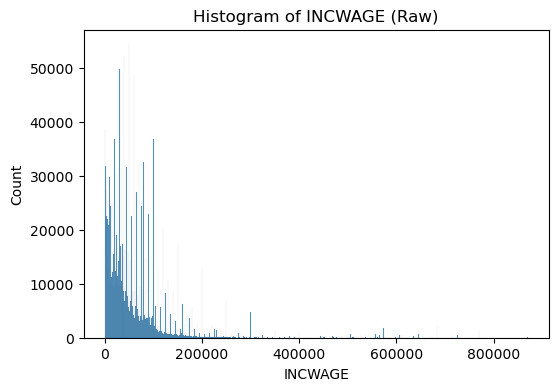

In [85]:
plt.figure(figsize=(6,4))
sns.histplot(df["INCWAGE"], kde=False)
plt.title("Histogram of INCWAGE (Raw)")
plt.show()

In [16]:
df["log_incwage"] = np.log(df["INCWAGE"]) #Create a log(INCWAGE) variable

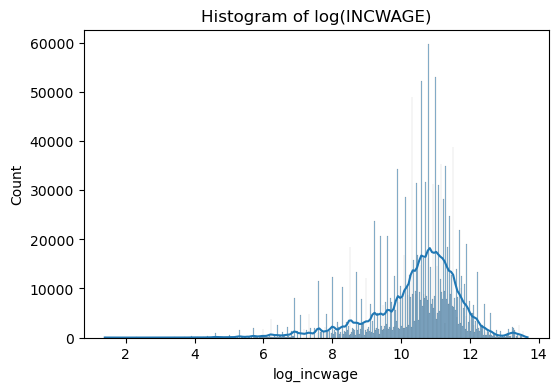

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df["log_incwage"], kde=True)
plt.title("Histogram of log(INCWAGE)")
plt.show()

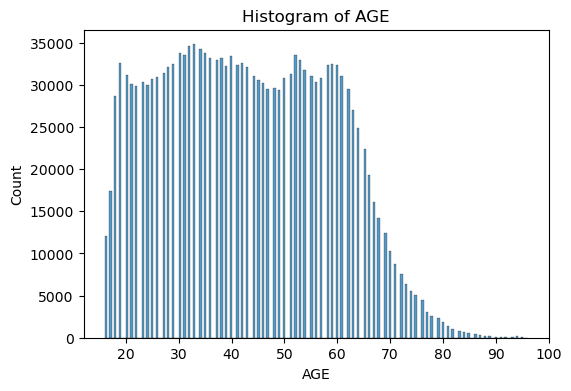

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df["AGE"], kde=False)
plt.title(f"Histogram of AGE")
plt.show()

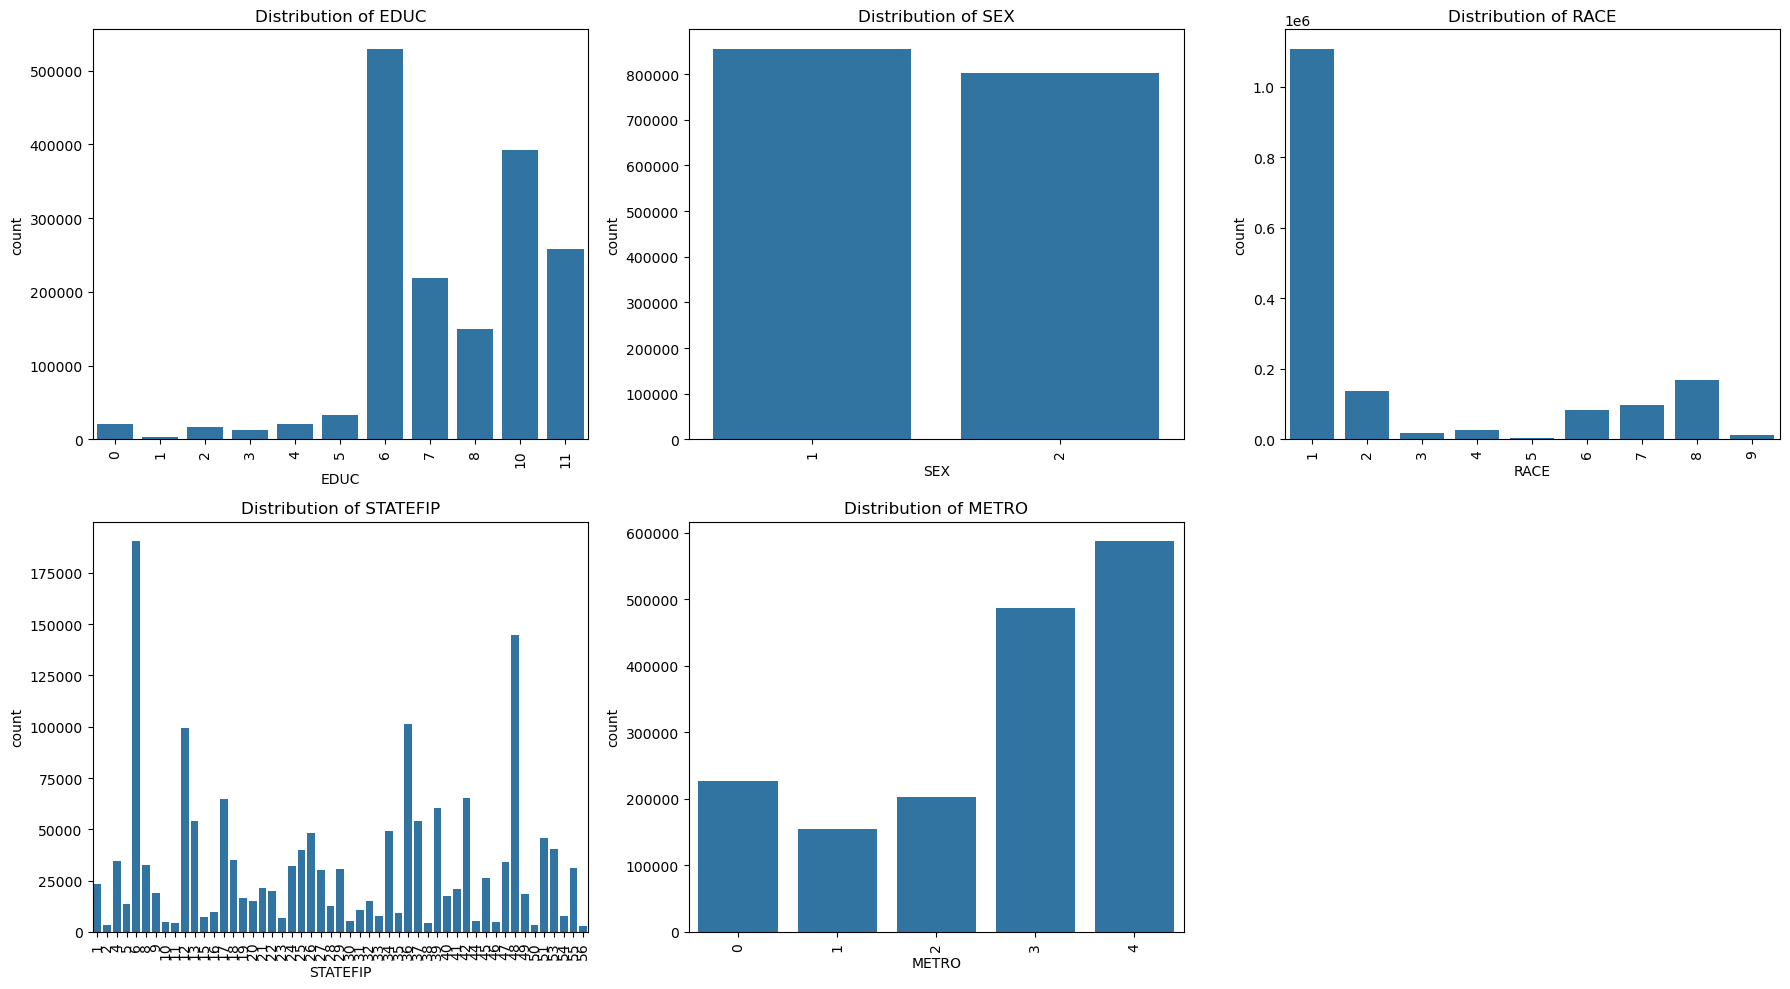

In [34]:
cat_vars = ["EDUC", "SEX", "RACE", "STATEFIP", "METRO"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)

if len(cat_vars) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

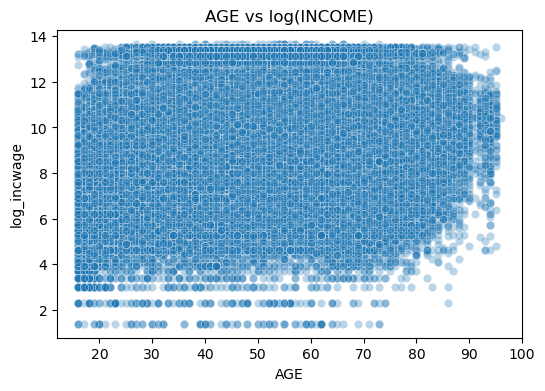

In [36]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["AGE"], y=df["log_incwage"], alpha=0.3)
plt.title("AGE vs log(INCOME)")
plt.show()

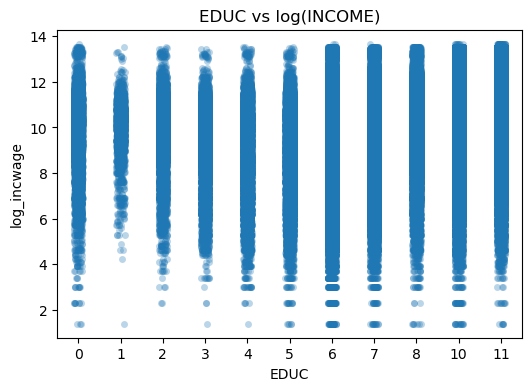

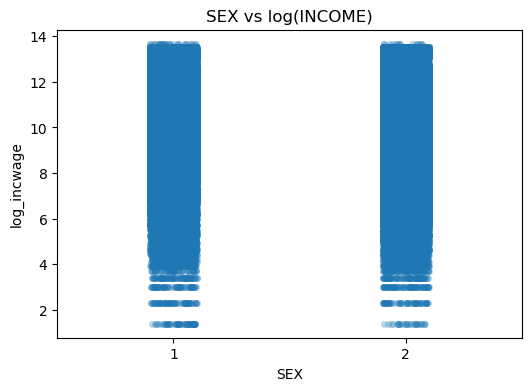

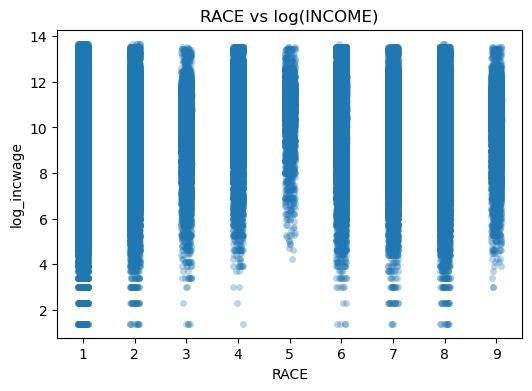

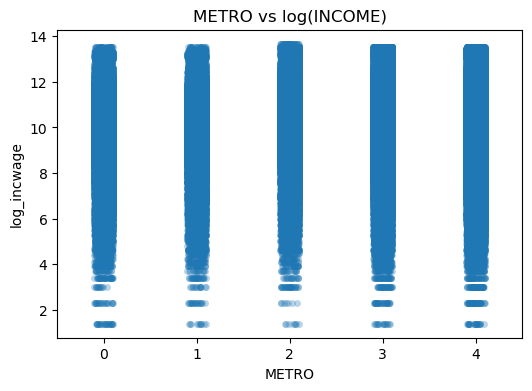

In [38]:
cat_vars = ["EDUC", "SEX", "RACE", "METRO"]

for col in cat_vars:
    plt.figure(figsize=(6,4))
    sns.stripplot(x=df[col], y=df["log_incwage"], jitter=True, alpha=0.3)
    plt.title(f"{col} vs log(INCOME)")
    plt.show()

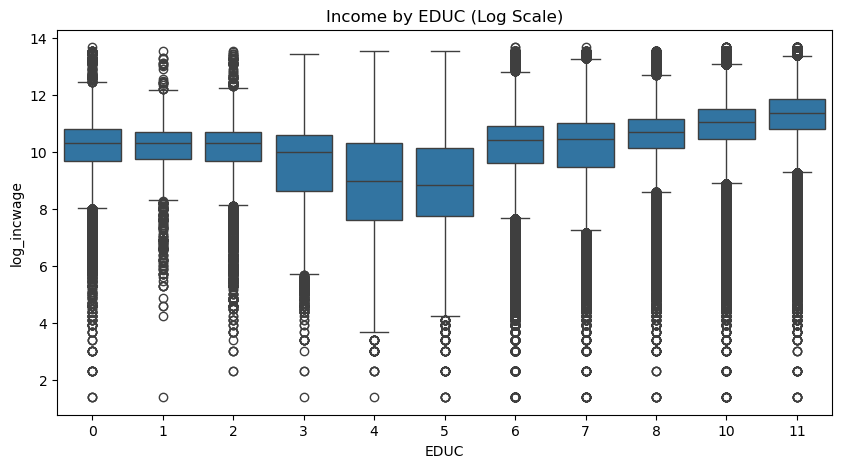

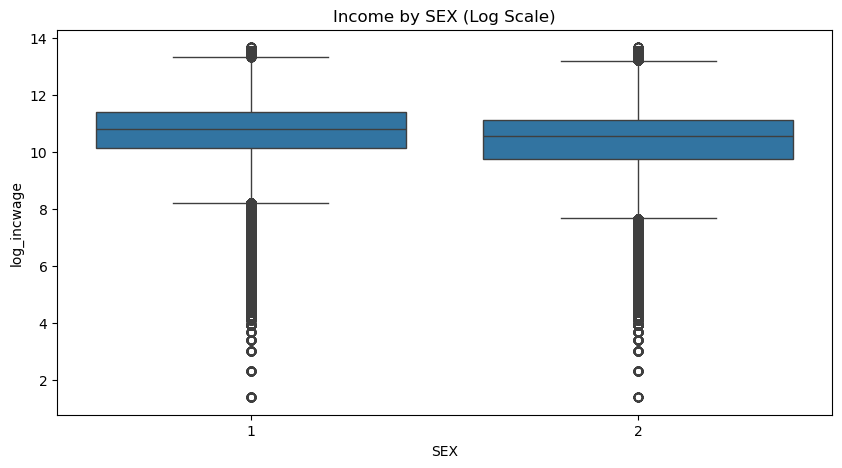

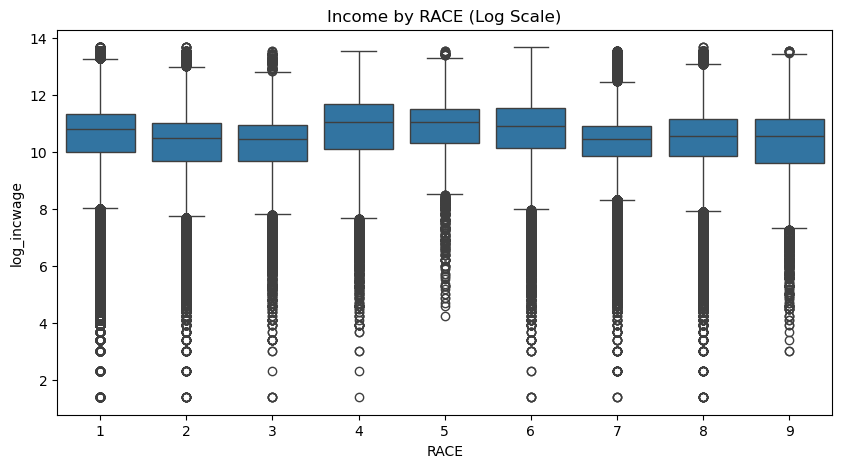

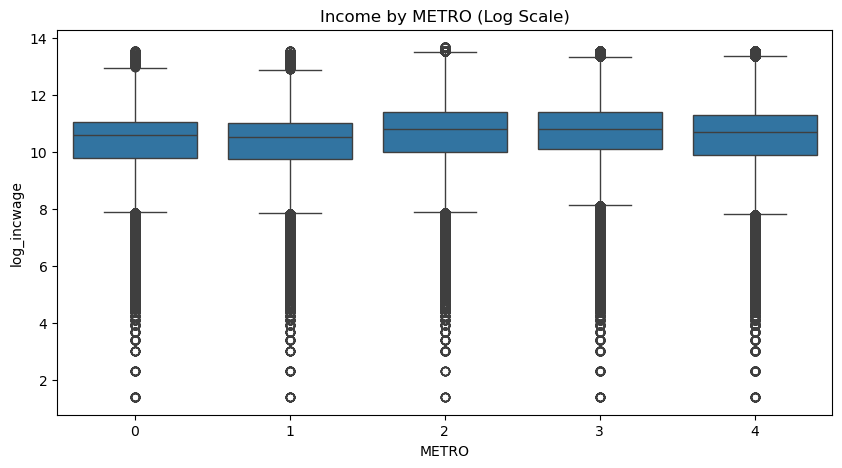

In [40]:
for col in cat_vars:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df["log_incwage"])
    plt.title(f"Income by {col} (Log Scale)")
    plt.show()

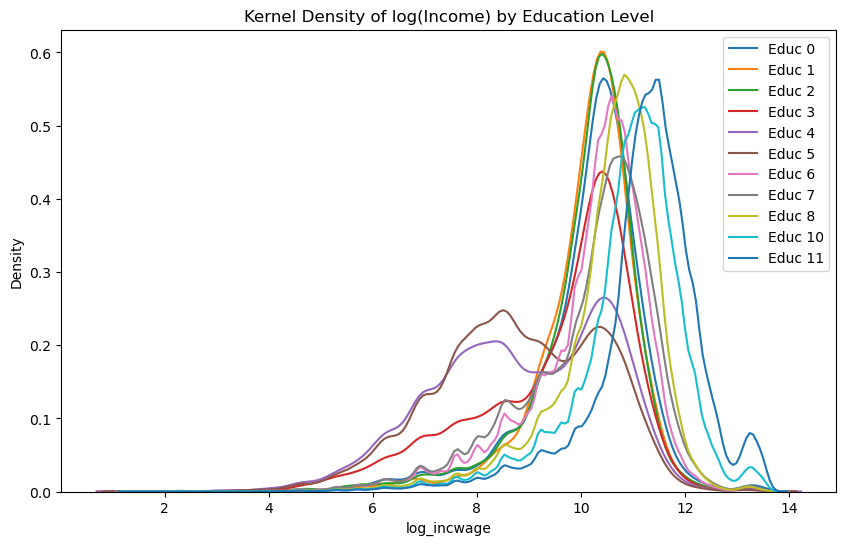

In [42]:
plt.figure(figsize=(10,6))
for level in sorted(df["EDUC"].unique()):
    sns.kdeplot(df[df["EDUC"]==level]["log_incwage"], label=f"Educ {level}", fill=False)
plt.legend()
plt.title("Kernel Density of log(Income) by Education Level")
plt.show()

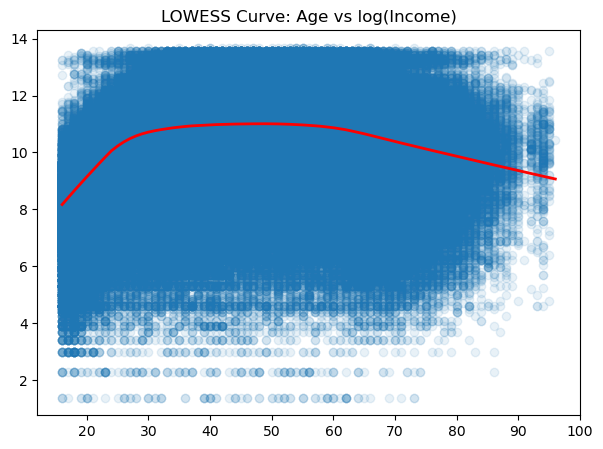

In [44]:
lowess = sm.nonparametric.lowess
z = lowess(df["log_incwage"], df["AGE"], frac=0.3)

plt.figure(figsize=(7,5))
plt.scatter(df["AGE"], df["log_incwage"], alpha=0.1)
plt.plot(z[:,0], z[:,1], color="red", linewidth=2)
plt.title("LOWESS Curve: Age vs log(Income)")
plt.show()

In [78]:
X_no_const = df[['EDUC','AGE','SEX','RACE','STATEFIP','OCC','METRO']] #Multicollinearity check
X = sm.add_constant(X_no_const)
 
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

   Variable        VIF
0     const  48.788178
1      EDUC   1.271506
2       AGE   1.019779
3       SEX   1.023900
4      RACE   1.050382
5  STATEFIP   1.018861
6       OCC   1.268757
7     METRO   1.036527


<span style="font-size:30px;">Modeling</span>

In [18]:
df["age2"] = df["AGE"] ** 2 #Create an AGE quadratic term for modeling
df["female"] = (df["SEX"] == 2).astype(int) 
df["metro_bin"] = df["METRO"].isin([2, 3, 4]).astype(int) #Simplify metro to codes to either nonmetro or metro

<span style="font-size:15px;">**Fixed Effects Model (Final Model)**</span>

In [51]:
formula = """
log_incwage ~ AGE + age2
             + female
             + metro_bin
             + C(EDUC)
             + C(RACE)
             + C(STATEFIP)
             + C(OCC)
             + C(EDUC):female
"""

model = smf.ols(formula=formula, data=df).fit(cov_type="HC1")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_incwage   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     1941.
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:21:51   Log-Likelihood:            -2.3052e+06
No. Observations:             1658035   AIC:                         4.612e+06
Df Residuals:                 1657424   BIC:                         4.619e+06
Df Model:                         610                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.2285 

In [63]:
bp_test = het_breuschpagan(model.resid, model.model.exog) #Run the Breush-Pagan test for heteroskedasticity check

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
for name, value in zip(labels, bp_test):
    print(f'{name}: {value}')

LM Statistic: 44827.011480147754
LM-Test p-value: 0.0
F-Statistic: 75.50108811210009
F-Test p-value: 0.0


In [60]:
SSE = model.ssr
SSR = model.ess
SST = model.centered_tss

print("SSE: ", SSE)
print("SSR: ", SSR)
print("SST: ", SST)
print("Check: ", SSR + SSE, " = ", SST)

SSE:  1565857.2031639547
SSR:  1225316.430112901
SST:  2791173.6332768556
Check:  2791173.6332768556  =  2791173.6332768556


<span style="font-size:15px;">**Simple Model (Excluding STATE & OCC)**</span>

In [53]:
formula2 = """
log_incwage ~ AGE + age2 + female + metro_bin
             + C(EDUC) * female
             + C(RACE)
"""
model2 = smf.ols(formula=formula2, data=df).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_incwage   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                 2.174e+04
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:23:22   Log-Likelihood:            -2.4522e+06
No. Observations:             1658035   AIC:                         4.905e+06
Df Residuals:                 1658002   BIC:                         4.905e+06
Df Model:                          32                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.3440 

<span style="font-size:15px;">**Alternate Model with Simplified Variables (STATE & OCC reduced)**</span>

Methodology:
- **sex**: 0 = Male, 1 = Female
- **educ**: convert to numerical **educ_yrs** using mapping function
- **race**: pd.get_dummies to create dummy variables, using "White" as reference category (the one we omit in the regression equation)
- **statefip**: map each state to one of 4 regions:

  1. South
  2. West
  3. Midwest
  4. Northeast

  then create dummies using "South" as the reference category
- **occ**: map each occupation code to one of 5 categories:

    1. Management, Business, Science, and Arts
    2. Service
    3. Sales and Office
    4. Natural Resources, Construction, and Maintenance
    5. Production, Transportation, and Material Moving

  then create dummies using "Management, Business, Science, and Arts" as the reference category

- **metro**: map to one of 3 simplified categories:
    
    1. In metro area
    2. Metro status indeterminate
    3. Not in metro area

  then create dummies using "In metro area" as the reference category

### Sex

In [30]:
df2 = pd.DataFrame()
df2 = df.copy()

# encode sex
df2["sex"] = df2["SEX"].replace({1: 0, 2: 1})

### Educ

In [39]:
# map years of education
educ_map = {
    0: 0,     #N/A or no schooling
    1: 2,     #Nursery school to grade 4
    2: 6.5,   #Grade 5, 6, 7, or 8
    3: 9,     #Grade 9
    4: 10,    #Grade 10
    5: 11,    #Grade 11
    6: 12,    #Grade 12
    7: 13,    #1 year of college
    8: 14,    #2 years of college
    10: 16,   #4 years of college
    11: 17    #5+ years of college

}
df2['educ_yrs'] = df2['EDUC'].map(educ_map)

### Race

In [46]:
df2['race'] = pd.Categorical(
    df2['RACE'],
    categories=[
        1,        #White <-- reference category
        8,        #Two major races      
        2,        #Black/African American
        7,        #Other race, nec
        6,        #Other Asian or Pacific Islander
        4,        #Chinese
        3,        #American Indian or Alaska Native
        9,        #Three or more major races
        5         #Japanese
    ],
    ordered=False
)

race_d = pd.get_dummies(df2['race'], drop_first=True, dtype=int)

### Statefip

In [53]:
# define region for each state
statefip_map = {
    6:  "West",        #California
    48: "South",       #Texas
    36: "Northeast",   #New York
    12: "South",       #Florida
    42: "Northeast",   #Pennsylvania
    17: "Midwest",     #Illinois
    39: "Midwest",     #Ohio
    13: "South",       #Georgia
    37: "South",       #North Carolina
    34: "Northeast",   #New Jersey
    26: "Midwest",     #Michigan
    51: "South",       #Virginia
    53: "West",        #Washington
    25: "Northeast",   #Massachusetts
    18: "Midwest",     #Indiana
    4:  "West",        #Arizona
    47: "South",       #Tennessee
    8:  "West",        #Colorado
    24: "Northeast",   #Maryland
    55: "Midwest",     #Wisconsin
    29: "Midwest",     #Missouri
    27: "Midwest",     #Minnesota
    45: "South",       #South Carolina
    1:  "South",       #Alabama
    21: "South",       #Kentucky
    41: "West",        #Oregon
    22: "South",       #Louisiana
    9:  "Northeast",   #Connecticut
    49: "West",        #Utah
    40: "South",       #Oklahoma
    19: "Midwest",     #Iowa
    32: "West",        #Nevada
    20: "Midwest",     #Kansas
    5:  "South",       #Arkansas
    28: "South",       #Mississippi
    31: "Midwest",     #Nebraska
    16: "West",        #Idaho
    35: "West",        #New Mexico
    54: "South",       #West Virginia
    33: "Northeast",   #New Hampshire
    15: "West",        #Hawaii
    23: "Northeast",   #Maine
    44: "Northeast",   #Rhode Island
    30: "West",        #Montana
    46: "Midwest",     #South Dakota
    10: "South",       #Delaware
    11: "South",       #District of Columbia
    38: "Midwest",     #North Dakota
    50: "Northeast",   #Vermont
    2:  "West",        #Alaska
    56: "West"         #Wyoming
}

df2['region'] = df2['STATEFIP'].map(statefip_map)

In [57]:
df2['region'] = pd.Categorical(
    df2['region'],
    categories=[
        "South",                 # <-- reference category
        "West",
        "Midwest",
        "Northeast",
    ],
    ordered=False
)

region_d = pd.get_dummies(df2['region'], drop_first=True, dtype=int)

### Occ

In [62]:
def map_occ_group(code):
    if 10 <= code <= 3550:
        return "Management, Business, Science, and Arts"
    elif 3601 <= code <= 4655:
        return "Service"
    elif 4700 <= code <= 5940:
        return "Sales and Office"
    elif 6005 <= code <= 7640:
        return "Natural Resources, Construction, and Maintenance"
    elif 7700 <= code <= 9920:
        return "Production, Transportation, and Material Moving"

df2['occ_group'] = df2['OCC'].apply(map_occ_group)

occ_group_d = pd.get_dummies(df2['occ_group'], drop_first=True, dtype=int)

### Metro

In [67]:
# map metro
metro_map = {
    4: "In metro area", #In metropolitan area: Central/principal city status indeterminable (mixed)
    3: "In metro area", #In metropolitan area: Not in central/principal city
    0: "Metro status indeterminate", #Metropolitan status indeterminable (mixed)
    2: "In metro area", #In metropolitan area: In central/principal city
    1: "Not in metro area", #Not in metropolitan area
} 
df2['metro_status'] = df2['METRO'].map(metro_map)

metro_d = pd.get_dummies(df2['metro_status'], drop_first=True, dtype=int)

## Regression

In [74]:
X = pd.concat([df2[['educ_yrs','AGE','age2','sex']], race_d, region_d, occ_group_d, metro_d], axis=1)

X = sm.add_constant(X)

# drop NAN (104)
X.dropna(inplace=True)

y = df2['log_incwage']

In [76]:
model3 = sm.OLS(y, X).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_incwage   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                 3.533e+04
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:07:54   Log-Likelihood:            -2.4334e+06
No. Observations:             1658035   AIC:                         4.867e+06
Df Residuals:                 1658013   BIC:                         4.867e+06
Df Model:                          21                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------